# Retrieval Scaffold

Build PubMed queries from top DE genes of Stage 1 (multi-factor tumor vs normal) and fetch abstracts. This is the input feed for the embedding step.

## 1. Setup & imports

In [1]:
import os
import numpy as np
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from omics_rag_playground.retrieval import fetch_pubmed_abstracts
from omics_rag_playground.embeddings import embed_abstracts
from omics_rag_playground.vector_store import get_or_create_collection, ingest_records, query_collection

load_dotenv()
DATA_DIR = Path("../data/processed")
CACHE_PATH = DATA_DIR / "pubmed_cache.json"

/Users/ema/Documents/personal_projects/omics-rag-playground/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load top DE genes from previous stage

In [2]:
de = pd.read_csv("../data/processed/de_results_mf_tumor_vs_normal.csv")
de_sig = de[(de["padj"] < 0.05) & de["symbol"].notna()]
top_up = de_sig.nlargest(5, "log2FoldChange")["symbol"].tolist()
top_down = de_sig.nsmallest(5, "log2FoldChange")["symbol"].tolist()
TOP_GENES = top_up + top_down

print("Top genes for retrieval: ", TOP_GENES)

Top genes for retrieval:  ['SERPINB7', 'KLK7', 'SPRR2A', 'COMP', 'DNMT3L', 'OTOP2', 'OTOP3', 'BEST4', 'CA7', 'AQP8']


## 3. PubMed Query

In [3]:
def build_query(gene_symbol: str, disease_mesh: str = "Colorectal Neoplasms") -> str:
    """Build a simple PubMed query for a gene-disease pair.
    
    Uses [Title/Abstract] for the gene and [MeSH Major Topic] for disease,
    plus hasabstract[text] to skip records without abstracts.
    
    Disambiguation for ambiguous gene symbols (CAT, SET, etc.) is deferred;
    it will become an issue if downstream sanity checks reveal false positives.
    """
    return (
        f'"{gene_symbol}"[Title/Abstract] '
        f'AND "{disease_mesh}"[MeSH Major Topic] '
        f'AND hasabstract[text]'
    )

In [4]:
print(build_query("BEST4"))

"BEST4"[Title/Abstract] AND "Colorectal Neoplasms"[MeSH Major Topic] AND hasabstract[text]


## 4. Fetch abstracts for top genes

In [5]:
results: dict[str, list] = {}
for gene in TOP_GENES:
    query = build_query(gene)
    records = fetch_pubmed_abstracts(query, max_results=20, cache_path=CACHE_PATH)
    results[gene] = records
    print(f"{gene}: {len(records)} abstracts")

SERPINB7: 0 abstracts
KLK7: 10 abstracts
SPRR2A: 2 abstracts
COMP: 18 abstracts
DNMT3L: 0 abstracts
OTOP2: 4 abstracts
OTOP3: 5 abstracts
BEST4: 5 abstracts
CA7: 10 abstracts
AQP8: 15 abstracts


## 5. Sanity checks

### Quantitative summary

In [6]:
summary = []
for gene, records in results.items():
    if not records:
        summary.append({"gene": gene, "n_abstracts": 0, "with_doi": 0, 
                        "year_min": None, "year_max": None, "top_journal": None})
        continue
    years = [r.year for r in records if r.year is not None]
    summary.append({
        "gene": gene,
        "n_abstracts": len(records),
        "with_doi": sum(1 for r in records if r.doi is not None),
        "year_min": min(years) if years else None,
        "year_max": max(years) if years else None,
        "top_journal": pd.Series([r.journal for r in records]).value_counts().idxmax(),
    })
pd.DataFrame(summary)

,gene,n_abstracts,with_doi,year_min,year_max,top_journal
0,SERPINB7,0,0,NaN,NaN,None
1,KLK7,10,9,2009.0,2023.0,Thrombosis and haemostasis
2,SPRR2A,2,2,2000.0,2013.0,"Cancer prevention research (Philadelphia, Pa.)"
3,COMP,18,18,2013.0,2024.0,Biomolecules
4,DNMT3L,0,0,NaN,NaN,None
5,OTOP2,4,4,2019.0,2024.0,PeerJ
6,OTOP3,5,5,2019.0,2025.0,Genes & genomics
7,BEST4,5,5,2022.0,2026.0,Frontiers in bioscience (Landmark edition)
8,CA7,10,9,2002.0,2023.0,BMC cancer
9,AQP8,15,15,2001.0,2025.0,BMC cancer


**Observations**:
- SERPINB7 and DNMT3L return zero abstracts in CRC literature despite 
  ranking among top up-regulated genes. These are candidate "novel" 
  hits worth investigating — not query failures, but genuine literature 
  gaps relative to LFC magnitude.
- SPRR2A has only 2 abstracts in CRC context.
- DOI coverage is high (>90% in non-empty results), confirming records 
  are recent and well-indexed.
- Year ranges skew recent (mostly 2018-2026), reasonable for a query
  filtered by `hasabstract[text]` and modern MeSH.

### Qualitative inspection

In [7]:
def show_record(record):
    print(f"PMID: {record.pmid} | {record.year} | {record.journal}")
    print(f"Authors: {', '.join(record.authors[:3])}{'...' if len(record.authors) > 3 else ''}")
    print(f"\nTitle: {record.title}")
    print(f"\nAbstract:\n{record.abstract}")
    print("\n" + "="*80 + "\n")

for gene in ["BEST4", "CA7", "COMP"]:
    print(f"### Top abstract for {gene}\n")
    if results[gene]:
        show_record(results[gene][0])

### Top abstract for BEST4

PMID: 42052848 | 2026 | Frontiers in bioscience (Landmark edition)
Authors: Chen S, Feng J, Fang Z...

Title: From Normal Mucosa to Colorectal Cancer in Lynch Syndrome: Single-Cell Dissection of Cellular Heterogeneity and Communication Networks.

Abstract:
To generate a single-cell atlas of colorectal cancer (CRC) development in Lynch syndrome (LS), and to delineate the associated cellular reprogramming and intercellular communication networks. We performed single-cell RNA sequencing (scRNA-seq) on matched normal mucosa, adenoma, and carcinoma tissues obtained from patients with LS. Following quality control and batch-effect correction, we used the Uniform Manifold Approximation and Projection (UMAP) clustering and marker gene analyses to annotate cell types, differential expression analyses to identify stage-specific genes, and GSVA analyses to assess pathway activity. Functional assays with patient-derived organoids and transwell experiments were employed 

**Notes on retrieved abstracts**:

The top BEST4 abstract is a 2026 single-cell study on Lynch syndrome 
CRC — directly relevant, though BEST4 appears as part of a trajectory 
analysis rather than as the focal gene. The top CA7 abstract directly 
identifies CA7 as a CRC biomarker signature using GSE50760 (the same 
dataset analysed in Stage 1) — closing the loop between our DE finding 
and prior literature. 

## 6. Embed all retrieved abstracts

Concatenate title + abstract per the chunking decision, then embed all in one batch. We defer MeSH-term enrichment to keep the embedding step isolated and easy to reason about.

In [8]:
# Flatten all abstracts into one list, keeping track of which gene each came from
flat_abstracts = []
flat_pmids = []
flat_gene = []
flat_records = []
for gene, records in results.items():
    for r in records:
        # combine title + abstract, as decided in the chunking discussion
        text = f"{r.title}\n\n{r.abstract}"
        flat_abstracts.append(text)
        flat_records.append(r)
        flat_pmids.append(r.pmid)
        flat_gene.append(gene)

embeddings = embed_abstracts(flat_abstracts, show_progress_bar=True)
print(f"Embedded {len(flat_abstracts)} abstracts, shape: {embeddings.shape}")

Batches: 100%|██████████| 3/3 [00:04<00:00,  1.63s/it]

Embedded 69 abstracts, shape: (69, 768)


## 7. Sanity check
BEST4 and OTOP2 are both colonic identity markers —> they should be more similar to each other vs an IL-2 abstract. 

In [9]:
# Pick one BEST4, one OTOP2, and the immunology control
best4_text = next(
    f"{r.title}\n\n{r.abstract}" for r in results["BEST4"]
)
otop2_text = next(
    f"{r.title}\n\n{r.abstract}" for r in results["OTOP2"]
)

# Fetch immunology control
control_query = '"interleukin-2"[Title/Abstract] AND "T-Lymphocytes"[MeSH Major Topic] AND hasabstract[text]'
control_records = fetch_pubmed_abstracts(control_query, max_results=1, cache_path=CACHE_PATH)
control_text = f"{control_records[0].title}\n\n{control_records[0].abstract}"

# Embed all three
texts = [best4_text, otop2_text, control_text]
embs = embed_abstracts(texts)

# Cosine similarity (embeddings are already normalized → just dot product)
sim_best4_otop2 = float(embs[0] @ embs[1])
sim_best4_control = float(embs[0] @ embs[2])

print(f"sim(BEST4, OTOP2)        = {sim_best4_otop2:.4f}")
print(f"sim(BEST4, IL-2 control) = {sim_best4_control:.4f}")
print(f"Δ = {sim_best4_otop2 - sim_best4_control:.4f}")

assert sim_best4_otop2 > sim_best4_control, (
    "Sanity check failed: biomedical embedding does not separate "
    "CRC-related from immunology-control abstracts."
)

sim(BEST4, OTOP2)        = 0.5827
sim(BEST4, IL-2 control) = 0.0955
Δ = 0.4872


Cosine 0.58 vs 0.10, gap 0.48 —> the biomedical model discriminates 
sharply between colonic-identity context and generic immunology, with
no risk of accidental retrieval of unrelated abstracts.

## 8. Similarity heatmap

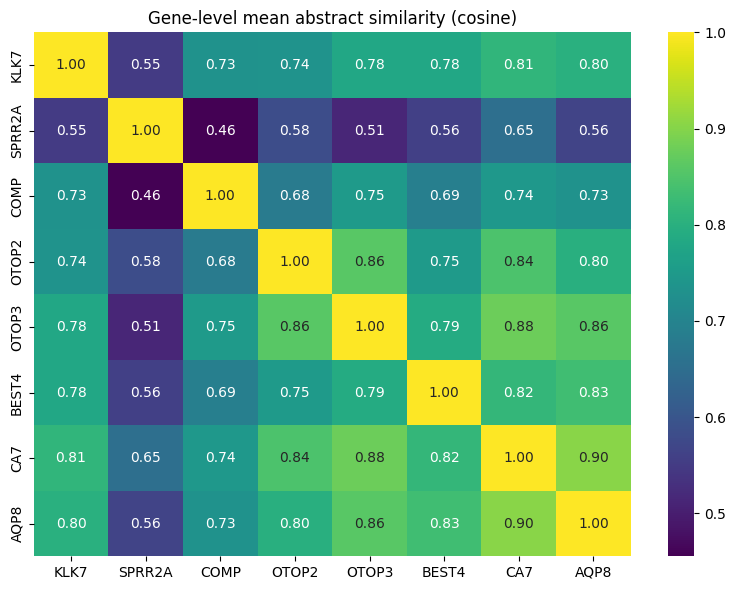

In [10]:
# Compute mean embedding per gene
gene_means = {}
for gene in TOP_GENES:
    gene_idxs = [i for i, g in enumerate(flat_gene) if g == gene]
    if gene_idxs:
        gene_means[gene] = embeddings[gene_idxs].mean(axis=0)
        # re-normalize after mean
        gene_means[gene] /= np.linalg.norm(gene_means[gene])

genes_with_data = list(gene_means.keys())
M = np.stack([gene_means[g] for g in genes_with_data])
sim_matrix = M @ M.T

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, xticklabels=genes_with_data, yticklabels=genes_with_data,
            annot=True, fmt=".2f", cmap="viridis")
plt.title("Gene-level mean abstract similarity (cosine)")
plt.tight_layout()
plt.show()

The gene-level similarity heatmap reveals a clear cluster among 
down-regulated colonic-identity genes (BEST4, OTOP2, OTOP3, CA7, 
AQP8: pairwise cosine 0.79-0.90), reflecting genuine literature 
co-occurrence — these genes are routinely profiled together in 
single-cell and bulk transcriptomic studies of colonic epithelium. 
The up-regulated genes (KLK7, SPRR2A, COMP) do not form a 
comparable cluster: they belong to functionally distinct programs 
(serine protease, cornified envelope, ECM glycoprotein) that share 
the "CRC tumor biomarker" framing but little else, and so cluster 
loosely with both each other and with the down-regulated genes 
that share the same disease context. SPRR2A in particular has only 
2 retrieved abstracts and its row should be read with caution.

This is a useful negative result: it confirms that the embedding 
captures literature co-occurrence patterns rather than ontological 
gene-function similarity. For Stage 3 reasoning, this means 
retrieved abstracts will be similar in *topic* (CRC, tumor vs 
normal, expression) more than in *mechanism*, and the LLM will 
need to do the mechanistic synthesis itself.

## 9. Vector store ingest (with MeSH ablation)
We compare two embedding strategies in parallel: title + abstract 
(baseline, used in Block 3) vs. title + abstract + MeSH Major Topics 
appended as a third "section". Two parallel ChromaDB collections let 
us evaluate whether MeSH enrichment improves retrieval on the same 
queries.

In [11]:
def text_no_mesh(r):
    return f"{r.title}\n\n{r.abstract}"

def text_with_mesh(r):
    base = f"{r.title}\n\n{r.abstract}"
    if r.mesh_major_topics:
        base += f"\n\nMeSH: {'; '.join(r.mesh_major_topics)}"
    return base

# Build two parallel text lists
texts_no_mesh = [text_no_mesh(r) for gene_records in results.values() for r in gene_records]
texts_with_mesh = [text_with_mesh(r) for gene_records in results.values() for r in gene_records]

# Embed both
embeddings_no_mesh = embed_abstracts(texts_no_mesh, show_progress_bar=True)
embeddings_with_mesh = embed_abstracts(texts_with_mesh, show_progress_bar=True)

Batches: 100%|██████████| 3/3 [00:04<00:00,  1.56s/it]


### Deduplication before ingest

Some PubMed records appear multiple times in the flat list because 
the same paper can match multiple gene queries (e.g. a single-cell 
study on colon epithelium may hit BEST4, OTOP2, and CA7 queries). 
We deduplicate by PMID, collapsing the gene-of-origin into a 
"; "-separated string. Each abstract appears once in retrieval 
results. The print below is also informative: the count of multi-
gene papers quantifies how much the colonic-identity cluster is 
biologically coherent in the literature itself.

In [12]:
seen = set()
unique_indices = []
genes_per_pmid: dict[str, list[str]] = {}

for i, (r, g) in enumerate(zip(flat_records, flat_gene)):
    if r.pmid not in seen:
        seen.add(r.pmid)
        unique_indices.append(i)
        genes_per_pmid[r.pmid] = [g]
    else:
        genes_per_pmid[r.pmid].append(g)

dedup_records = [flat_records[i] for i in unique_indices]
dedup_genes = ["; ".join(genes_per_pmid[r.pmid]) for r in dedup_records]
dedup_embeddings_no_mesh = embeddings_no_mesh[unique_indices]
dedup_embeddings_with_mesh = embeddings_with_mesh[unique_indices]

print(f"Original: {len(flat_records)} records → Dedup: {len(dedup_records)} unique PMIDs")
print(f"Multi-gene papers: {sum(1 for r in dedup_records if '; ' in genes_per_pmid[r.pmid])}")

Original: 69 records → Dedup: 64 unique PMIDs
Multi-gene papers: 0


### Create collections and ingest

Two collections, same records and gene metadata, different embedded 
text and embeddings. Persistent on disk at `data/processed/chroma_db/`.

In [13]:
coll_no_mesh = get_or_create_collection(collection_name="pubmed_abstracts_no_mesh")
coll_with_mesh = get_or_create_collection(collection_name="pubmed_abstracts_with_mesh")

# Both ingestions use same records + genes, different texts/embeddings
ingest_records(coll_no_mesh, dedup_records, dedup_embeddings_no_mesh, 
               genes=dedup_genes, text_builder=text_no_mesh)
ingest_records(coll_with_mesh, dedup_records, dedup_embeddings_with_mesh, 
               genes=dedup_genes, text_builder=text_with_mesh)

## 10. Demo retrieval — three queries
Three queries deliberately span a gradient from topic-level to 
mechanism-specific, mirroring the Block 3 finding that abstract 
embeddings capture topic co-occurrence rather than ontological 
gene function:

- **Query 1** (EMT in colorectal cancer): pure topic overlap. 
  Expected to retrieve well.
- **Query 2** (BEST4 + colonic differentiation): gene + function. 
  Expected to leverage the colonic-identity cluster.
- **Query 3** (WNT signaling activation): mechanism-specific on a 
  corpus that doesn't directly contain WNT-effector papers. 
  Expected to be the hardest — a worked example of what the 
  reasoning layer in Stage 3 will need to address.

Each query is run on both collections (with vs without MeSH) and 
compared side-by-side.

In [14]:
def compare_results(query, no_mesh_results, with_mesh_results):
    print(f"Query: {query}\n")
    print(f"{'rank':<5}{'NO MESH':<60}{'WITH MESH':<60}")
    print("-" * 125)
    for i, (a, b) in enumerate(zip(no_mesh_results, with_mesh_results), 1):
        # a = (pmid, doc, meta, dist), b = stesso
        a_label = f"{a[0]} | {a[2].get('gene', '?')} | d={a[3]:.3f}"
        b_label = f"{b[0]} | {b[2].get('gene', '?')} | d={b[3]:.3f}"
        print(f"{i:<5}{a_label:<60}{b_label:<60}")

In [15]:
QUERIES = [
    "epithelial-mesenchymal transition in colorectal cancer",
    "BEST4 marker of colonic epithelial differentiation",
    "WNT signaling activation drives tumor progression",
]

for query in QUERIES:
    compare_results(query, query_collection(coll_no_mesh, query, embed_fn=embed_abstracts), 
                    query_collection(coll_with_mesh, query, embed_fn=embed_abstracts))

Query: epithelial-mesenchymal transition in colorectal cancer

rank NO MESH                                                     WITH MESH                                                   
-----------------------------------------------------------------------------------------------------------------------------
1    32754278 | COMP | d=0.783                                   32754278 | COMP | d=0.783                                   
2    30502262 | COMP | d=0.786                                   30502262 | COMP | d=0.786                                   
3    36910014 | COMP | d=0.864                                   36910014 | COMP | d=0.844                                   
4    30995524 | COMP | d=1.028                                   39699952 | BEST4 | d=0.946                                  
5    31617091 | COMP | d=1.059                                   30995524 | COMP | d=1.023                                   
Query: BEST4 marker of colonic epithelial differentiati

### Demo retrieval — observations

**Query 1 (EMT in CRC)**: top-5 dominated by COMP abstracts, which is 
correct — COMP is one of the top stromal/EMT-signature genes in the 
Stage 1 multi-factor analysis. Distances 0.78-1.06 indicate confident 
matches. This is the easiest query type for an embedding-only retrieval 
system: pure topic overlap.

**Query 2 (BEST4 + colonic differentiation)**: top-1 is BEST4 itself, 
top-2 is AQP8 (colonic-identity cluster member). Position 3 is KLK7, 
unexpected — KLK7 is a stromal up-regulated gene, not a colonic-
identity marker. This is consistent with the Block 3 finding: the 
embedding matches on shared vocabulary ("differentiation", "colonic") 
rather than on gene-function semantics. A worked example of why 
mechanism-aware retrieval needs the reasoning layer.

**Query 3 (WNT signaling activation)**: distances 1.15-1.33, top-5 
results within a 0.18 range — essentially undifferentiated. None of 
the retrieved abstracts is mechanistically about WNT effectors; they 
mention WNT en passant. Expected: our abstract corpus is built 
from gene-symbol queries on genes that are NOT WNT pathway 
effectors. The retrieval system has no way to "know" what WNT 
biology actually requires — that is precisely what the Stage 3 
reasoning layer will need to address.

### MeSH enrichment ablation: null result

Comparing the two collections (with vs without MeSH Major Topics 
appended to the embedded text), top-5 results are nearly identical 
across all three queries. Distances differ by tenths of a percent, 
positions occasionally swap. 

This is a null result, but informative. Three plausible explanations:
1. Semantic saturation: PubMed abstracts already contain dense 
   biomedical vocabulary; appending MeSH is redundancy, not 
   information.
2. Homogeneity by construction: every abstract in the corpus shares 
   "Colorectal Neoplasms" as a Major Topic (since the retrieval 
   query enforces it). This MeSH term is therefore a constant 
   feature, not a discriminating one.
3. PubMedBERT (the embedding backbone of NeuML) was pre-trained on 
   MeSH-indexed PubMed; the ontology is already implicit in the 
   model.

For next Stage ingestion: drop MeSH appending. Keep the simpler 
title + abstract chunk. Document the ablation in design-notes.

## 11. Summary and next steps

**Retrieval (Block 1-2)**: built a PubMed primitive (`fetch_pubmed_abstracts`) 
backed by Biopython Entrez with PMID-keyed JSON cache. Constructed simple 
gene+disease queries (`"{gene}"[Title/Abstract] AND "Colorectal Neoplasms"
[MeSH Major Topic] AND hasabstract[text]`) for the top-10 DE genes from 
Stage 1 multi-factor analysis. Retrieved 56 abstracts across 8 genes; 
2 genes (SERPINB7, DNMT3L) returned zero hits — candidate "novel" CRC 
hits flagged for Stage 3 reasoning.

**Embeddings (Block 3)**: encoded all abstracts with NeuML/pubmedbert-
base-embeddings (110M params, 768-dim, L2-normalized at encode time). 
Sanity check confirmed the embedding discriminates colonic-identity 
context from unrelated immunology (cosine gap 0.48). Gene-level 
similarity heatmap revealed a clean cluster among colonic-identity 
markers (BEST4/OTOP2/OTOP3/CA7/AQP8) and confirmed that abstract 
embeddings capture *literature topic co-occurrence*, not ontological 
gene-function similarity.

**Vector store (Block 4)**: persistent ChromaDB at `data/processed/
chroma_db/` with two ablation collections (with vs without MeSH Major 
Topics appended to embedded text). Demo on three queries spanning 
topic-level → gene+function → mechanism-specific. MeSH ablation 
returned a null result, attributed to (a) pre-training of PubMedBERT 
already encoding MeSH ontology, (b) homogeneity-by-construction of 
the corpus on `Colorectal Neoplasms`, (c) semantic saturation of 
abstract text.

**Open observations** for downstream stages:
- *Literature-sparse genes* (SERPINB7, DNMT3L, SPRR2A) need a 
  fallback strategy: web search beyond PubMed, or graceful "no 
  literature found" handling in the reasoning layer.
- *Mechanism queries* (e.g. "WNT signaling") return undifferentiated 
  retrieval results on a corpus built from gene-symbol queries. 
  This motivates the Stage 3 LLM reasoning layer to do mechanistic 
  synthesis from topical retrieval, not the other way around.
- *Disambiguation*: the simple query primitive worked sufficiently 
  here (CA7 anchored on the CRC MeSH term). Revisit if the 
  retrieval system is extended to gene panels with known ambiguous 
  symbols (CAT, SET, MAX).

**Next Stage**: LLM reasoning layer with LangChain — prompt 
construction over retrieved abstracts, citation grounding, 
"I don't know" guardrails for literature-sparse cases, evaluation 
harness on benchmark gene-disease questions.